In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Default_Fin.csv")

In [3]:
df.head(5)

,Index,Employed,Bank Balance,Annual Salary,Defaulted?
0,1,1,8754.36,532339.56,0
1,2,0,9806.16,145273.56,0
2,3,1,12882.60,381205.68,0
3,4,1,6351.00,428453.88,0
4,5,1,9427.92,461562.00,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          10000 non-null  int64  
 1   Employed       10000 non-null  int64  
 2   Bank Balance   10000 non-null  float64
 3   Annual Salary  10000 non-null  float64
 4   Defaulted?     10000 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


In [5]:
df.columns

Index(['Index', 'Employed', 'Bank Balance', 'Annual Salary', 'Defaulted?'], dtype='object')

In [6]:
df.isnull()

,Index,Employed,Bank Balance,Annual Salary,Defaulted?
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
9995,False,False,False,False,False
9996,False,False,False,False,False
9997,False,False,False,False,False
9998,False,False,False,False,False


In [7]:
df.isnull().sum()

Index            0
Employed         0
Bank Balance     0
Annual Salary    0
Defaulted?       0
dtype: int64

In [8]:
df.shape

(10000, 5)

In [15]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.drop_duplicates(df)

,Employed,Bank Balance,Annual Salary,Defaulted?
0,1,8754.36,532339.56,0
1,0,9806.16,145273.56,0
2,1,12882.60,381205.68,0
3,1,6351.00,428453.88,0
4,1,9427.92,461562.00,0
...,...,...,...,...
9995,1,8538.72,635908.56,0
9996,1,9095.52,235928.64,0
9997,1,10144.92,703633.92,0
9998,1,18828.12,440029.32,0


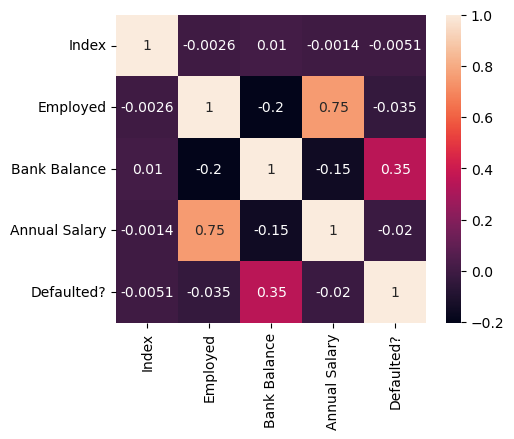

In [9]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(), annot=True)
plt.show()

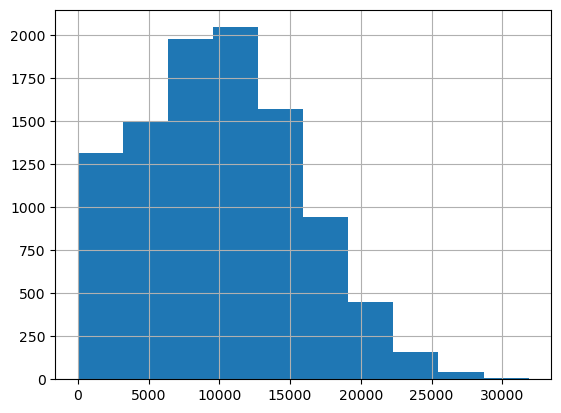

In [17]:
df["Bank Balance"].hist()
plt.show()

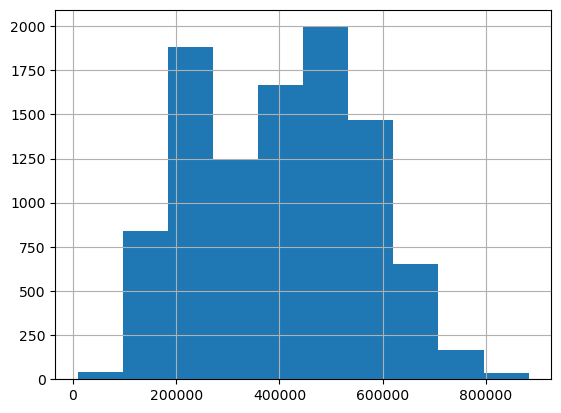

In [16]:
df["Annual Salary"].hist()
plt.show()

In [10]:
df.drop("Index", axis = 1, inplace = True)

In [11]:
df

,Employed,Bank Balance,Annual Salary,Defaulted?
0,1,8754.36,532339.56,0
1,0,9806.16,145273.56,0
2,1,12882.60,381205.68,0
3,1,6351.00,428453.88,0
4,1,9427.92,461562.00,0
...,...,...,...,...
9995,1,8538.72,635908.56,0
9996,1,9095.52,235928.64,0
9997,1,10144.92,703633.92,0
9998,1,18828.12,440029.32,0


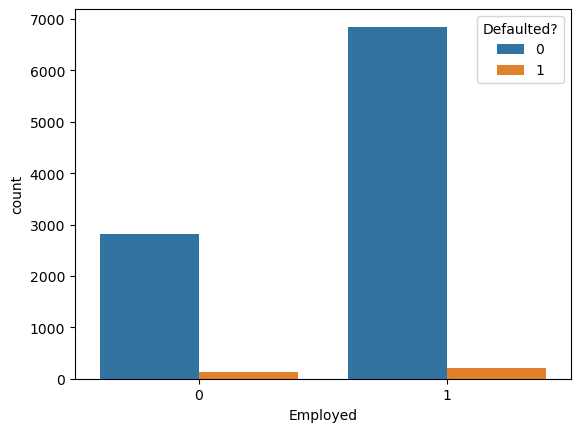

In [12]:
sns.countplot(x = "Employed", hue = "Defaulted?", data = df)
plt.show()

In [13]:
df["Defaulted?"].unique()

array([0, 1])

In [14]:
df["Defaulted?"].value_counts()

Defaulted?
0    9667
1     333
Name: count, dtype: int64

In [25]:
y = df["Defaulted?"]

In [26]:
X = df.drop("Defaulted?", axis = 1)

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
dt_model = DecisionTreeClassifier(max_depth = 1, random_state=42)

In [32]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
dt_predict = dt_model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

In [36]:
dt_accuracy = accuracy_score(
    y_test,
    dt_predict
)

In [37]:
print(dt_accuracy)

0.9635


In [38]:
from sklearn.metrics import confusion_matrix

In [39]:
confusion_matrix(
    y_test,
    dt_predict
)

array([[1900,   31],
       [  42,   27]])